#Jax Optimization

**By Edwin Tembo... Work in Progress as of 06-11-2026.**

*A.I. used for Latex formating.*

Based on https://jax-ml.github.io/scaling-book/


# Section 1: Roofline Analysis

**Question 3**: Taking the setup from Question 2, make a roofline plot of peak FLOPs/s vs.
B for
F=D=4096 and
F=D=1024. Use the exact number of bytes loaded, not an approximation.



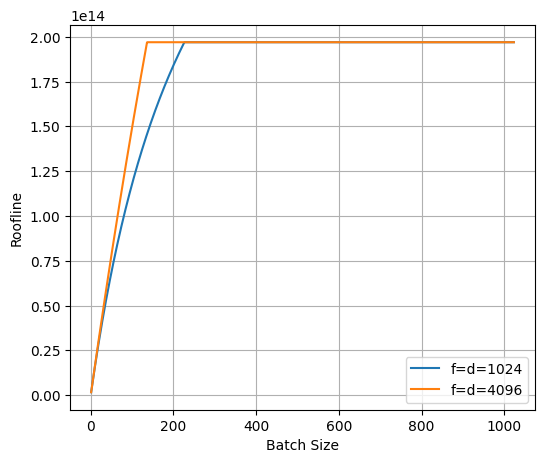

In [ ]:
# @title Roofline Plot


from matplotlib import pyplot as plt
import numpy as np
import math

bs = np.arange(1 , 1024)

def matmul_roofline(b, d, f, bandwidth=8.2e11, accel_flops_speed = 1.97e14):
   """

   Calculates the theoretical maximum capacity of a chip , assuming perfect overlap between
   Processor/ Accelerator Time and Data Movement Time For a mixed precision matmul
   with BD[FP16] and DF-[INT8]
   b : int - Represents Batch size
   d : int - Represents the number of records
   f : int - Represents the dimensions in the data
   """
   total_flops     = 2*b*d*f     ##Engineering Convention for matmul
   total_bytes     = 2*b*d + d*f + 2*b*f

   time_math        = total_flops/accel_flops_speed
   time_comm        = total_bytes/bandwidth

   lower_bound_time = np.maximum(time_math, time_comm)

   ##---calculate the roofline ----------------------
   return total_flops/lower_bound_time

roofline_0 = matmul_roofline(bs, 1024, 1024)
roofline_1 = matmul_roofline(bs, 4096, 4096)


plt.figure(figsize=(6,5))

plt.plot( bs, roofline_0, label="f=d=1024" )
plt.plot( bs, roofline_1, label="f=d=4096" )
plt.legend()
plt.xlabel("Batch Size")
plt.ylabel("Roofline")
plt.grid()
plt.show()
#

Question 4: What if we wanted to perform
int8[B,D]⋅ int8[B,D,F]→int8[B,F] where we imagine having a different matrix for each batch element. What is the arithmetic intensity of this operation?

In [ ]:
#@title Arithmetic Intensity
from sympy import symbols, Eq, init_printing
b,d,f = symbols('b d f')

init_printing()
flops = 2*b*d*f
bytes = b*d + b*d*f + b*f

arithmetic_intensity = flops/bytes
arithmetic_intensity




     2⋅b⋅d⋅f     
─────────────────
b⋅d⋅f + b⋅d + b⋅f

**Question 5.** [Memory Rooflines for GPUs]: Using the spec sheet provided by NVIDIA for the H100 SXM, calculate the batch size at which a bfloat16 matrix multiplication will become compute-bound. Note that the Tensor Core FLOPs numbers are twice the true value since they're only achievable with structured sparsity.



**Answer**

$$
\text{Arithmetic Intensity} = \frac{\text{Total FLOPs}}{\text{Total Bytes}}
$$

For fp16 $[B \times D]\ \cdot\ [D \times F]\ \rightarrow\ [B \times F]$ matmul (2 bytes/value):

$$
\text{Total FLOPs} = 2BDF \quad (\text{engineering convention})
$$

$$
\text{Total Bytes} = 2BD + 2DF + 2BF
$$

$$
\text{Arithmetic Intensity} = \frac{2BDF}{2BD + 2DF + 2BF}
$$

Assuming $B \ll D$ and $B \ll F$:

$$
\text{Arithmetic Intensity}_{\text{matmul}} \approx \frac{2BDF}{2DF} = B
$$

We can then use the roofline inequality to find the batch size at which the system becomes compute-bound:

$$
B \geq \frac{\text{Peak FLOPs/s}}{\text{Peak Bandwidth (B/s)}}
$$


In [ ]:
# @title Intensity(matmul) > Intentsity(acceletor) to become compute bound

#https://www.nvidia.com/en-us/data-center/h100/

##FP16 Tensor Core*	1,979 teraFLOPS
##GPU Memory Bandwidth	3.35TB/s
accel_speed= 1.979e15 * 0.5
bandwidth  = 3.35e12
arithmetic_intensity = accel_speed/bandwidth
##So according to intensity(matmul) > intentsity(acceletor) to become compute bound
b = arithmetic_intensity
int(b)

295

#Section 2: Scaling

In [ ]:
import numpy as np
import pandas as pd
from sympy import symbols, Eq, init_printing

init_printing()

**Question 1**[bounding LLM latency]: Say you want to sample from a 200B parameter model in bf16 that's split across 32 TPU v4p. How long would it take to load all the parameters from HBM into the systolic array? Hint: use the numbers above.

In [ ]:
def time_to_load(param_bytes, num_tpu_v4p, hbm_bandwidth):
  bytes_per_TPU = param_bytes/num_tpu_v4p
  time_to_load  = bytes_per_TPU/hbm_bandwidth
  return time_to_load

param_bytes   = 200e9 *2
num_tpu_v4p   = 32
hbm_bandwidth = 1.2e12

time_to_load = time_to_load(param_bytes, num_tpu_v4p, hbm_bandwidth)

print("The time to load all the data accross 32 v4p TPUs is ~ " + str(np.round(time_to_load *1000, decimals=4)) + " ms")

The time to load all the data accross 32 v4p TPUs is ~ 10.4167 ms


**Question 2 [TPU details]** : Consider a full TPU v5e pod. How many total CPU hosts are there? How many TPU TensorCores? What is the total FLOPs/s for the whole pod? What is the total HBM? Do the same exercise for TPU v5p pod.

In [ ]:
#@title TPU Time Functions

def get_tpu_specs( chip_name,
                   num_tpu_chips,
                   host_size,
                   chips_per_tpu_core,
                   flops_per_sec_chip_fp16,
                   flops_per_sec_chip_int8,
                   hbm_capacity_per_chip,

                ):

 out_dir = {}
 num_hosts                = num_tpu_chips/host_size
 num_tpu_cores            = chips_per_tpu_core * num_tpu_chips
 total_flops_per_sec_fp16 = num_tpu_chips * flops_per_sec_chip_fp16
 total_flops_per_sec_int8 = num_tpu_chips * flops_per_sec_chip_int8
 total_hbm                = num_tpu_chips * hbm_capacity_per_chip
 out_dir['chip_name']     = chip_name
 out_dir['num_hosts']     = num_hosts
 out_dir['tpu_cores']     = num_tpu_cores
 out_dir['total_flops_per_sec_fp16'] = total_flops_per_sec_fp16
 out_dir['total_flops_per_sec_int8'] = total_flops_per_sec_int8
 out_dir['total_hbm']    = total_hbm
 return out_dir

##v5e
num_tpu_chips           = 16 * 16
host_size               = 4 * 2
chips_per_tpu_core      = 1
flops_per_sec_chip_fp16 = 1.97e14
flops_per_sec_chip_int8 = 3.94e14
hbm_capacity_per_chip   = 16e9

specs              = get_tpu_specs('v5e',
                                   num_tpu_chips,
                                   host_size,
                                   chips_per_tpu_core,
                                   flops_per_sec_chip_fp16,
                                   flops_per_sec_chip_int8,
                                   hbm_capacity_per_chip
                                  )

##v5p
num_tpu_chips           = 16*20*28
host_size               = 2*2*1
chips_per_tpu_core      = 2
flops_per_sec_chip_fp16 = 4.59e14
flops_per_sec_chip_int8 = 9.18e14
hbm_capacity_per_chip   = 96e9

specs2              = get_tpu_specs('v5p',
                                   num_tpu_chips,
                                   host_size,
                                   chips_per_tpu_core,
                                   flops_per_sec_chip_fp16,
                                   flops_per_sec_chip_int8,
                                   hbm_capacity_per_chip
                                  )

df = pd.DataFrame(specs, index=[''])
df2 = pd.DataFrame(specs2, index=[''])
pd.concat([df, df2], axis=0)
#
#



,chip_name,num_hosts,tpu_cores,total_flops_per_sec_fp16,total_flops_per_sec_int8,total_hbm
,v5e,32.0,256,5.043200e+16,1.008640e+17,4.096000e+12
,v5p,2240.0,17920,4.112640e+18,8.225280e+18,8.601600e+14


**Question 3 [PCIe operational intensity]**: Imagine we’re forced to store a big weight matrix
A of type bf16[D,F], and a batch of activations x of type bf16[B,D] in host DRAM and want to do a matrix multiplication on them. This is running on a single host, and we’re using a single TPU v6e chip attached to it. You can assume B≪D, and F=4D (we’ll see in future chapters why these are reasonable assumptions). What is the smallest batch size B we need to remain FLOPs bound over PCIe? Assume PCIe bandwidth of 1.6e10 bytes / second.

To be compute bound:

$T_{compute}$ > $T_{comm}$

$T_{compute}$ = $\frac {\text{Total Flops}}{\text {Accel FLOPS/s}}$

$T_{comm}$  = $\frac{\text{Total Bytes}}{\text{Bandwidth}}$

${\text{Total FLOPS}}$ $\text{for a matmul}$ = ${2BDF}$

${\text{Total Bytes (fp16)}}$ =  ${\frac{2BDF}{2BD + 2DF + 2BF}}$

$\text{since}$ $T_{compute}$ > $T_{comm}$  => ${\frac{2BDF}{9.20e14}}$ > ${\frac{2BD + 2DF + 2BF}{1.6e10}}$  => ${\frac{2BDF}{2BD + 2DF + 2BF}}$ > ${\frac{9.20e14}{1.6e10}}$

$\text {Assuming B is small in comparison to D and  F and  F= 4D, we can approximate the total bytes transferred as}$ ${8D^2}$

 ${\frac{2BDF}{ 8D^2 }}$ > ${\frac{9.20e14}{1.6e10}}$ => ${\frac{8BD^2 }{ 8D^2 }}$ > ${\frac{9.20e14}{1.6e10}}$

${\text{Therefore:}}$




In [ ]:
accel_flops_1chip_v6e = 9.20e14
pcie_bandwidth        = 1.6e10

B = accel_flops_1chip_v6e/pcie_bandwidth

print( f"The smallest batch size required to remain FLOPs bound over PCIE is {int(B)}")

The smallest batch size required to remain FLOPs bound over PCIE is 57500


**Question 4 [general matmul latency]:** Let’s say we want to multiply a weight matrix int8[16384, 4096] by an activation matrix of size int8[B, 4096] where B is some unknown batch size. Let’s say we’re on 1 TPU v5e to start.

1. How long will this multiplication take as a function of B? Hint: it may help to calculate how long it will take to load the arrays from HBM and how long the multiplication will actually take. Which is bottlenecking you?

2. What if we wanted to run this operation out of VMEM? How long would it take as a function of B?

**From HBM**

${\text{total_bytes (int8)}}$ = $16384 * 4096 + 4096B$ = $67108864 + 4096B + 16348B$

${\text{total_flops}}$ = $2 * 16384 * 4096*B$

$\small{\text{(Due to transpose, B takes the position we've generally used for F thus far.)}}$

${\text{hbm_bandwidth = 8.2e11}}$

${\text{accel_flops_speed_v5e_int8= 3.94e14}}$

${t_{comm_v5e}}$ ${\text{ = total_bytes/bandwidth = }}$ $\frac{67108864+4096B+16348B}{8.2 \times 10^{11}}$


${t_{math_v5e}}$ ${\text{ = total_flops/accel_flops_speed_v5e_int8 = }}$ $\frac{134217728B}{3.94 \times 10^{14}}$

${\text{total_time}}$ = ${\text{max}}$(${t_{math_v5e}}$, ${t_{comm_v5e}}$)

${\text{To be FLOPs bound => ${t_{math_v5e}}$ > ${t_{comm_v5e}}$ => B > 259}}$












**From VMEM**

vmem bandwidth is  22x faster than HBM.

${t_{comm_v5e}}$ ${\text{ = total_bytes/bandwidth = }}$ $\frac{67108864+4096B+16348B}{8.2 \times 22 \times 10^{11}}$

${\text{To be FLOPs bound => ${t_{math_v5e}}$ > ${t_{comm_v5e}}$ => B > 11}}$





**Question 5 [ICI bandwidth]:** Let's say we have a TPU v5e 4x4 slice. Let's say we want to send an array of type bf16[8, 128, 8192] from TPU{0,0} to TPU{3, 3}. Let's say the per-hop latency for TPU v5e is 1μs.

How soon will the first byte arrive at its destination?

How long will the total transfer take?

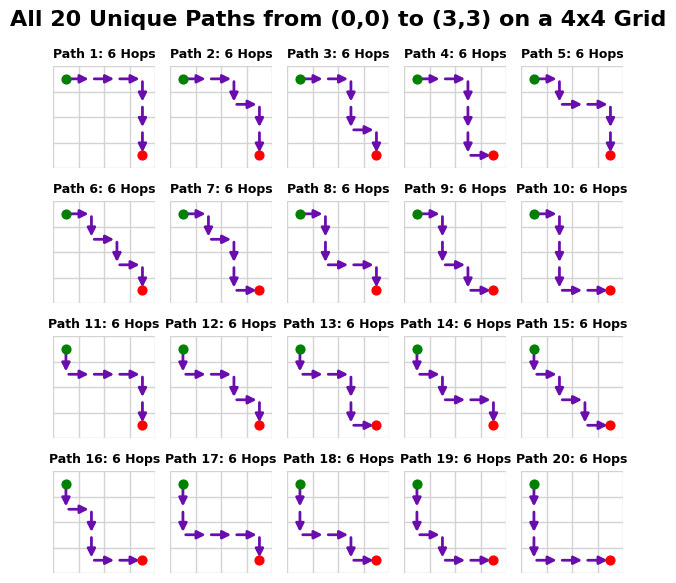

In [ ]:
#@title Latency Analysis 4x4 TPU slice

import matplotlib.pyplot as plt
import numpy as np

# Recursively find all valid down/right paths from (0,0) to (3,3)
paths = []
def find_paths(r, c, current_path):
    if r == 3 and c == 3:
        paths.append(list(current_path))
        return
    if c < 3: # Move right
        find_paths(r, c + 1, current_path + [(r, c + 1)])
    if r < 3: # Move down
        find_paths(r + 1, c, current_path + [(r + 1, c)])

# Start path-finding from top-left (0,0)
find_paths(0, 0, [(0, 0)])

# Create a 4x5 subplot grid to show all 20 unique paths distinctly
fig, axes = plt.subplots(4, 5, figsize=(6, 6))
axes = axes.flatten()

for i, path in enumerate(paths):
    ax = axes[i]

    # Draw background 4x4 grid boxes
    for x in range(5):
        ax.plot([x, x], [0, 4], color='#d3d3d3', linestyle='-', linewidth=1, zorder=1)
        ax.plot([0, 4], [x, x], color='#d3d3d3', linestyle='-', linewidth=1, zorder=1)

    # Convert matrix coordinates (r, c) to visual center coordinates (x, y)
    # Matrix (0,0) is top-left -> mapped to graph (0.5, 3.5)
    x_coords = [p[1] + 0.5 for p in path]
    y_coords = [3 - p[0] + 0.5 for p in path]

    # Draw directional arrows along the path sequence
    for j in range(len(path) - 1):
        ax.annotate('', xy=(x_coords[j+1], y_coords[j+1]), xytext=(x_coords[j], y_coords[j]),
                    arrowprops=dict(arrowstyle="-|>", color="#6a0dad", lw=2, mutation_scale=12, zorder=3))

    # Mark Start (Green) and End (Red) nodes
    ax.scatter(x_coords[0], y_coords[0], color='green', s=40, zorder=4, label='Start' if i==0 else "")
    ax.scatter(x_coords[-1], y_coords[-1], color='red', s=40, zorder=4, label='End' if i==0 else "")

    # Grid formatting
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_aspect('equal')
    ax.set_title(f"Path {i+1}: 6 Hops", fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle("All 20 Unique Paths from (0,0) to (3,3) on a 4x4 Grid", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


${\text{Lowest No. of hops from TPU(0,0) to TPU(3, 3) in 4 x 4 Slice = 6 right and 6 down for all possibilites.}}$

${\text{=> total_latency = 6μs each direction ( 2 possible simultaneous routes of 6 hops)}}$

${\text{=> total_bytes_per_route =}}$   $\frac{2 \times 8 \times 128 \times 8192}{2}$ ${\text{= 8388608}}$

${\text{=> ici_bandwith_v5e_per_hop  = 4.5e10}}$

${\text{=> total_transfer_time       =}}$ ${\frac{8388608}{4.5e10}}$ ${\text{~ 186μs + 6μs ~ 192μs}}$

${\small{\text{ Streaming serialization means data is transfered in tiny chunks, so the time it takes is ~ time of 1 hop + latency}}}$

${\text{i. First byte arrives in 6μs.}}$

${\text{ii. Total transfer takes ~192μs.}}$

**Hop Count: TPU(0,0) → TPU(3,3) in a 4×4 Slice**

Lowest number of hops = 6 right + 6 down (all possible routes).

$$
t_{\text{latency}} = 6\ \mu\text{s} \quad (\text{2 possible simultaneous routes of 6 hops})
$$

$$
\text{total_bytes_per_route}
= \frac{2 \times 8 \times 128 \times 8192}{2}
= 8{,}388{,}608\ \text{bytes}
$$

$$
\text{ici_bandwidth_v5e_per_hop} = 4.5 \times 10^{10}\ \text{B/s}
$$

$$
t_{\text{transfer}}
= \frac{8{,}388{,}608}{4.5 \times 10^{10}}
\approx 186\ \mu\text{s}
$$

$$
t_{\text{total}} = t_{\text{transfer}} + t_{\text{latency}} \approx 186 + 6 = 192\ \mu\text{s}
$$

> *Streaming serialization: data is transferred in tiny chunks, so total time ≈ time of 1 hop + latency.*
>
> i. First byte arrives in $6\ \mu\text{s}$.  
> ii. Full transfer completes in $\approx 192\ \mu\text{s}$.

**Question 6 [pulling it all together, hard]:** Imagine you have a big matrix A: int8[128 * 1024, 128 * 1024] sharded evenly across a TPU v5e 4x4 slice but offloaded to host DRAM on each chip. Let’s say you want to copy the entire array to TPU{0, 0} and multiply it by a vector bf16[8, 128 * 1024]. How long will this take? Hint: use the numbers above.

**Setup:**

$$
\text{matrix_dims} = [131072,\ 131072]
$$

$$
\text{v5e_host_size} = 4 \times 2, \qquad \text{num_hosts_for_4×4_slice} = 2
$$

$$
\text{total_matrix_bytes_per_host} = \frac{131072^2}{2} = 8{,}589{,}934{,}592\ \text{bytes}
$$

$$
\text{total_matrix_bytes_per_chip}
= \frac{131072^2}{16} = 1{,}073{,}741{,}824\ \text{bytes}
$$

$$
\text{PCIe bandwidth} = 1.6 \times 10^{10}\ \text{B/s} \quad (\text{per link, 16 PCIe links})
$$

---

**LEG 1: DRAM → HBM (per host)**

$$
t_{\text{LEG1}}
= \frac{\text{total_matrix_bytes_per_chip}}{\text{pcie_bandwidth}}
= \frac{1{,}073{,}741{,}824}{1.6 \times 10^{10}}
\approx 67\ \text{ms}
$$

---

**LEG 2: Over-Chip ICI → TPU(0,0)**

Data from 15 chips to 1 chip:

$$
\text{total_bytes}
= 131072^2 - \frac{131072^2}{16}
= 16{,}106{,}127{,}360\ \text{bytes}
$$

Two possible routes halve the load. Using the serialized streaming approximation:

$$
t_{\text{LEG2}}
= \frac{\text{total_bytes}}{\text{bandwidth}_{1\text{-hop}} \times 2\ \text{routes}}
= \frac{16{,}106{,}127{,}360}{4.5 \times 10^{10} \times 2}
\approx 178.95\ \text{ms}
$$

---

**LEG 3: HBM → MXU**

$$
B = D = 128 \times 1024 = 131{,}072, \qquad F = 8 \quad (\text{required transpose})
$$

$$
\text{HBM Bandwidth} = 8.2 \times 10^{11}\ \text{B/s}
$$

$$
\text{Total bytes (8-bit int)} = BD + DF + BF
= 131072^2 + 8 \times 131072 + 8 \times 131072
= 17{,}181{,}966{,}336\ \text{bytes}
$$

$$
t_{\text{LEG3}}
= \frac{17{,}181{,}966{,}336}{8.2 \times 10^{11}}
\approx 21\ \text{ms}
$$

---

**LEG 4: MATMUL** *(2BDF convention)*

$$
B = D = 128 \times 1024, \qquad F = 8 \quad (\text{required transpose})
$$

$$
\text{Total FLOPS} = 2BDF
= 2 \times (128 \times 1024) \times (128 \times 1024) \times 8
= 274{,}877{,}906{,}944
$$

$$
T_{\text{math}}
= \frac{274{,}877{,}906{,}944}{1.97 \times 10^{14}}
\approx 1.4\ \text{ms}
$$

---

**Summary** *(if perfect overlap — dominated by LEG 2):*

$$
\boxed{T_{\max} \approx 178.95\ \text{ms}}
$$

#Section 3: Tensor Sharding

**Pop Quiz [2D sharding across 1 axis]**: Consider an array fp32[1024, 4096] with sharding A[I_XY,J] and mesh {'X': 8, 'Y': 2}. How much data is held by each device? How much time would it take to load this array from HBM on H100s (assuming 3.4e12 memory bandwidth per chip)?

**Setup:**

$$
\text{fp32_bytes_per_value} = 4
$$

Sharding $A[I_{XY},\ J]$ on a mesh $\{'X': 8,\ 'Y': 2\}$:

$$
\text{shape_fraction_per_shard} = \left[\frac{1}{X \times Y},\ Y\right] = \left[\frac{1}{16},\ 1\right]
$$

$$
\text{actual_shape_per_shard} = \left[\frac{1}{16} \times 1024,\ 4096 \times 1\right] = [64,\ 4096]
$$

$$
\text{bytes_per_shard}
= \text{fp32_bytes_per_value} \times I_{XY} \times J
= 4 \times 64 \times 4096
= 1{,}048{,}576\ \text{bytes}
$$

---

**Load Time Calculation:**

$$
\text{hbm_bandwidth} = 3.4 \times 10^{12}\ \text{B/s}
$$

$$
t_{\text{load}}
= \frac{\text{total_bytes_per_shard}}{\text{hbm_bandwidth}}
= \frac{1{,}048{,}576}{3.4 \times 10^{12}}
\approx 0.308\ \mu\text{s}
$$








**Pop Quiz:** Let A be an array with shape int8[128, 2048], sharding

A[I_XY,J], and mesh Mesh({'X': 2, 'Y': 8, 'Z': 2}) (so 32 devices total). How much memory does A use per device? How much total memory does A use across all devices?

**Setup:**

Sharding $A[I_{XY},\ J]$ on a mesh $\{'X': 8,\ 'Y': 2,\ 'Z': 2\}$:

$$
 \text{total_shards =} {X \times Y \times Z = 32}
$$
$$
\text{shape_fraction_per_shard} = \left[\frac{1}{X \times Y},\ 1\right] = \left[\frac{1}{16},\ 1\right]
$$

$$
\text{actual_shape_per_shard} =  \left[\frac{1}{16} \times 128,\ 2048\right] = [8,\ 2048]
$$

---

**Answers:**

$$
\text{memory_per_shard (int8)} = 8 \times 2048 = 16{,}384\ \text{bytes}
$$

$$
\text{memory_across_all} = \text{memory_per_shard} \times \text{total_shards} = 524{,}288\ \text{bytes}
$$

Jax code running in Kaggle NoteBook with v5e-8  TPU Machine. https://www.kaggle.com/code/edwintembo/jax-sharding

**Pop Quiz 2 [AllGather time]:** Using the numbers from Part 2, how long does it take to perform the AllGatherY([EY, F]) → [E, F] on a TPU v5e with a 2D mesh {'X': 8, 'Y': 4}, E=2048, F=8192, in bfloat16? What about with E=256, F=256?

**Setup: Sharding on one Contracting Axis**

Bidirectional bandwidth is possible on inference chips like v5e when the axis has shape 16.
On Training Chips (v--p's), it occurs when the axis is a multiple of 4.
Here we use v5e with Y-axis shape $4 \Rightarrow$ unidirectional hop only.
Therefore we need $(N-1) = 3$ hops to perform the AllGather.

---

**For Reference:**

$$
T_{\text{Bidirectional AllGather}} = \max\!\left[\frac{T_{\min} \times X}{2},\ \frac{\text{total bytes}}{\text{bandwidth}_{\text{ici bidirectional}}}\right]
$$

$$
T_{\text{Unidirectional AllGather}} = \max\!\left[T_{\min} \times HOPS(N-1),\ \frac{\frac{\text{total_bytes}\times HOPS}{N}}{\text{bandwidth}_{\text{ici unidirectional}}}\right]
$$

$$
\text{HOPS = N-1 ; N = Y = 4}
$$

$$
\text{bandwidth}_{\text{ici bidirectional}} = 9.0 \times 10^{10}\ \text{B/s}
$$

$$
\text{bandwidth}_{\text{ici unidirectional}} = 4.5 \times 10^{10}\ \text{B/s}
$$

$$
\text{ici latency} = 1\ \mu\text{s}
$$

$$
\text{total bytes}_1\ (\text{bf16}) = 2 \times 2048 \times 8192 = 33{,}554{,}432\ \text{bytes}
$$

$$
\text{total bytes}_2\ (\text{bf16}) = 2 \times 256 \times 256 = 131{,}072\ \text{bytes}
$$

---

**Answers**

$$
T_{\text{overhead}} =  HOPS * latency = (4-1) * 1 \mu s = 3\mu s
$$

---

**i) Larger Array 2048x8192**

$$
T_{\text{AllGather}} =\frac{\frac{\text{total_bytes}\times HOPS}{N}}{\text{bandwidth}_{\text{ici unidirectional}}} \approx 559\ \mu\text{s}
$$

$$
\max\!\left[T_{\text{overhead}},\ T_{\text{AllGather}}\right] \approx \boxed{559\ \mu\text{s}}
$$

---

**ii) Smaller Array 256x256**

$$
T_{\text{AllGather}} = \frac{\frac{\text{total_bytes}\times HOPS}{N}}{\text{bandwidth}_{\text{ici unidirectional}}} \approx 2.18\ \mu\text{s}
$$

$$
\max\!\left[T_{\text{overhead}},\ T_{\text{AllGather}}\right] \approx \boxed{3\ \mu\text{s}}
$$


$$
 \text{These are just theorical calculations. In reality the times can be higher. (https://jax-ml.github.io/scaling-book/sharding/). Colab notebook (https://colab.research.google.com/drive/15tDZMfNqm2vJjvSzw5VC9qtSwc5td-oV?usp=sharing)}
$$

$$
\text{ For reference, multiple axis AllGather with bidirectional bandwidth formula:}
$$

$$
T_{\text{total}} = \max\!\left[\frac{T_{\min} \times \sum_i X_i}{2},\ \frac{\text{total bytes}}{\text{bandwidth}_{\text{ici bidirectional}} \times N_{\text{axis}}}\right]
$$

$$
\text{Where} \frac{T_{\min} \times \sum_i X_i}{2} \text{ is the length of the longest path in the TPU mesh.}
$$


